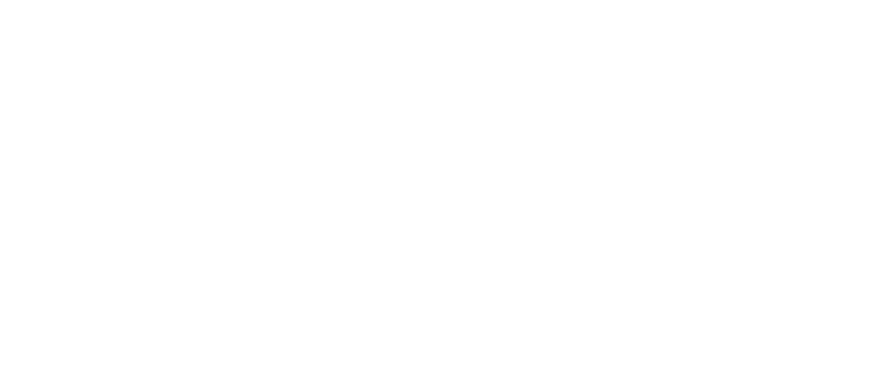

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
X, y = make_blobs(n_samples=400,
                  centers=4,
                  cluster_std=1.5,
                  random_state=42)

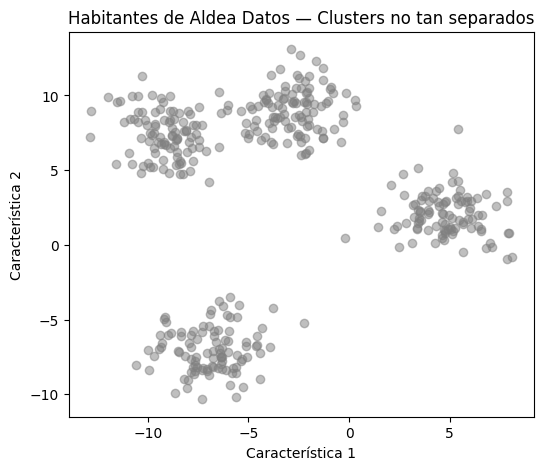

In [3]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c='gray', alpha=0.5)
plt.title("Habitantes de Aldea Datos — Clusters no tan separados")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()

In [4]:
silhouette_scores = []
inertias = [] # SSE
k_values = range(2, 8)

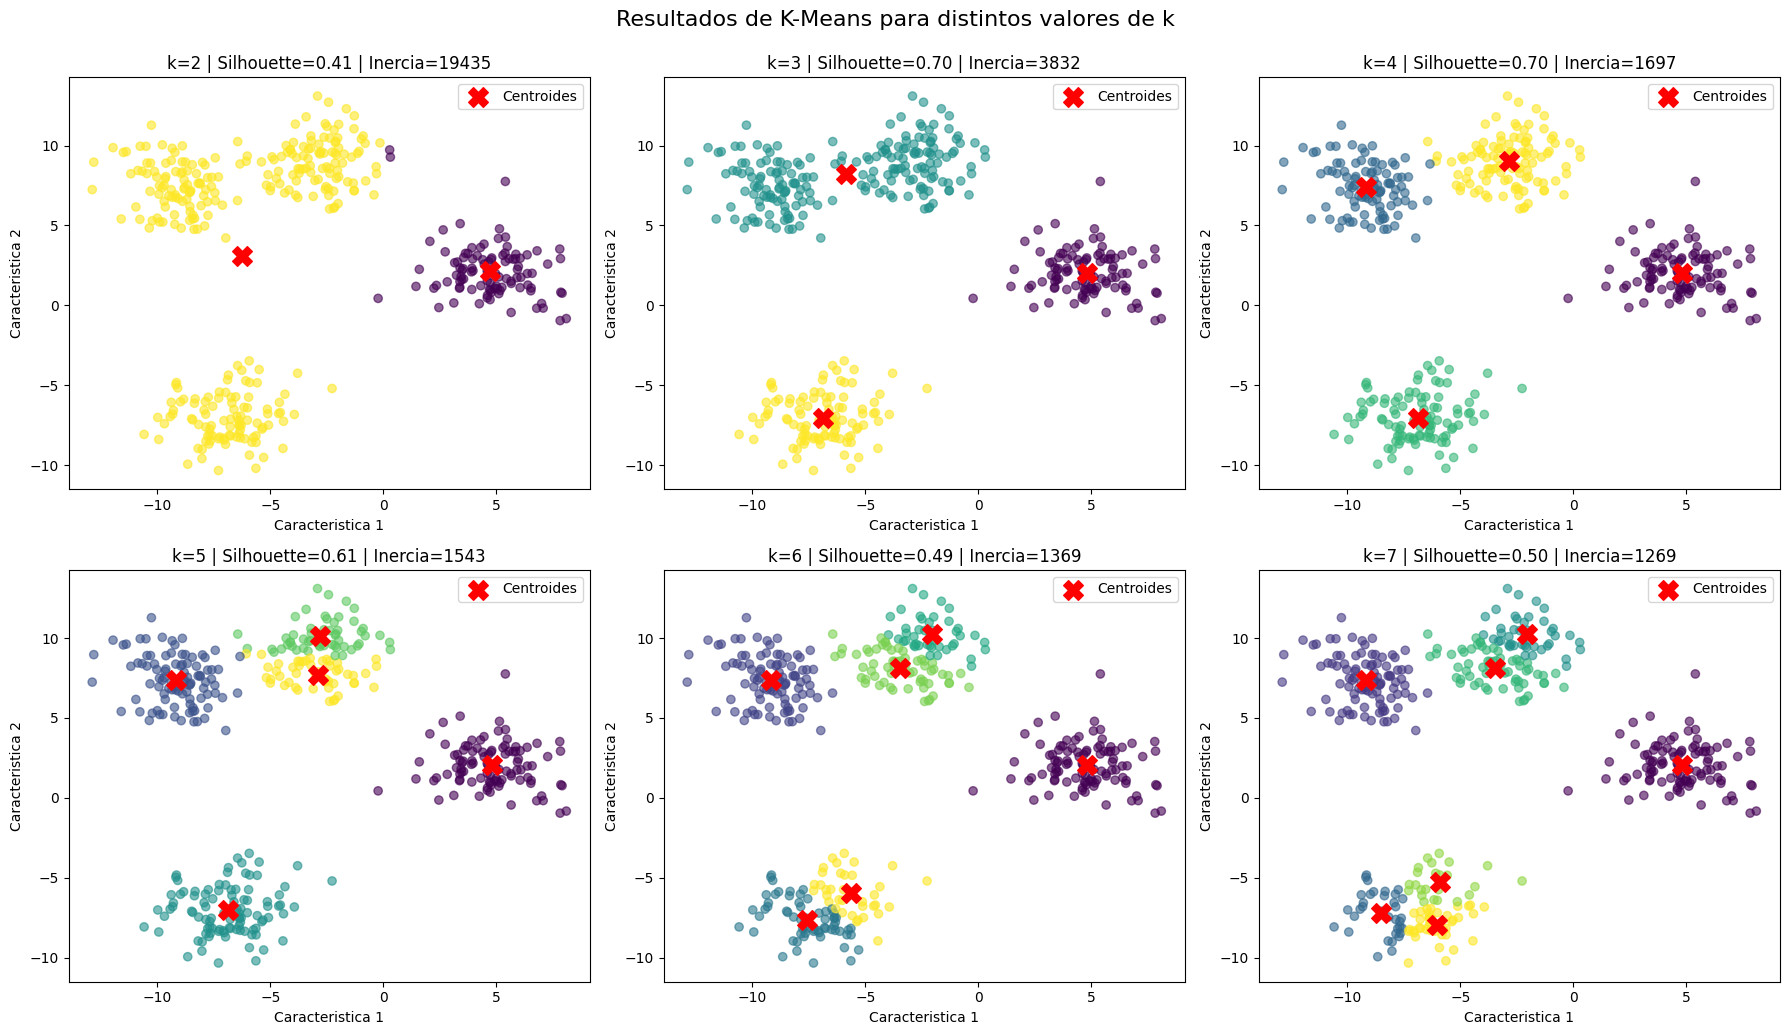

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
axs = axs.flatten()

for idx, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42)  # Define el numero de clusters
    labels = kmeans.fit_predict(X)                   # Aplica el modelo y obtiene las etiquetas
    centers = kmeans.cluster_centers_                # Obtiene las coordenadas de los centroides
    inertia = kmeans.inertia_                        # Inercia: suma de distancias intra-cluster
    score = silhouette_score(X, labels)              # Calcula el Silhouette Score

    silhouette_scores.append(score)
    inertias.append(inertia)


    axs[idx].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6)
    axs[idx].scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Centroides')
    axs[idx].set_title(f"k={k} | Silhouette={score:.2f} | Inercia={inertia:.0f}")
    axs[idx].set_xlabel("Caracteristica 1")
    axs[idx].set_ylabel("Caracteristica 2")
    axs[idx].legend()

plt.tight_layout()
plt.suptitle("Resultados de K-Means para distintos valores de k", fontsize=16, y=1.03)
plt.show()

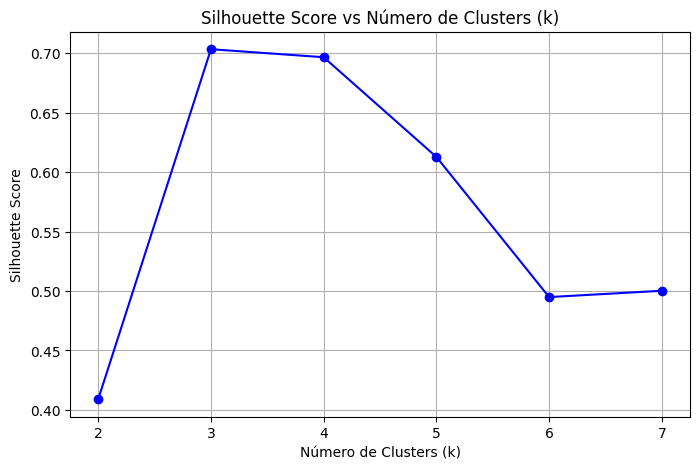

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', color='blue')
plt.title("Silhouette Score vs Número de Clusters (k)")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

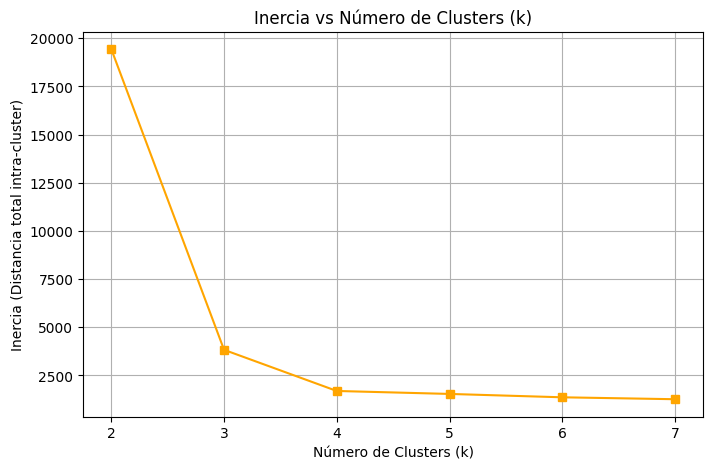

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='s', color='orange')
plt.title("Inercia vs Número de Clusters (k)")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inercia (Distancia total intra-cluster)")
plt.grid(True)
plt.show()

# **Preguntas**

1. **Si en la aldea hay una gran mayoría de personas en un grupo y muy pocos en otros, ¿cómo podría afectar esto la formación de los clústers? ¿Qué tipo de sesgo se podría generar en la agrupación?**


si unos miembros estan muy alejados de su grupo respectivo, puede afectar el centroide, dado que kmeans calcula el promedio de posicion de todos sus miembros y no puede identificar ruido.

2. **Supón que el nuevo habitante está muy lejos del resto de la aldea. ¿Qué implicaciones tiene esto para el modelo K-Means? ¿Cómo lo clasificaría el algoritmo y qué tan confiable sería esa asignación?**

esa asignacion seria de confiabilidad baja dado que como kmeans no puede identificar ruido, forzaria una asignacion, aunque este dato no pertenezca a ningun grupo

3. **Si un grupo de habitantes está ubicado entre dos clústers claramente formados, ¿cómo afecta esto al resultado del algoritmo? ¿Qué papel juega el valor de K en este tipo de situaciones?**  

dependiento la distancia a la que este este grupo de cada cluster puede suceder una de dos cosas,  
1 el grupo completo va a ser asignado a un cluster independientemente de su pertenencia o distancia  
2 el grupo puede ser dividido hasta k sub grupos para ser asignados a sus respectivos clusters si el sistema lo determina pertinente

4. **¿Cuál fue la cantidad óptima de clústers según los criterios mencionados en clase?**

3 dado que es donde se aprecia el codo de la grafica